# Phase 4: Exploratory Data Analysis (EDA)

## 1. Analysis Goals
In this notebook, we analyze:
1. Demographic distributions across Indian metros.
2. Income vs. plot budget alignment (3-5x multiplier rule).
3. Lead drop-off across the sales funnel.
4. Age-group purchase propensity (Section 6 of project guide).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

clean_path = os.path.join("..", "data", "real_estate_clean.csv")
df = pd.read_csv(clean_path)
print(f"Loaded {len(df)} records for EDA.")


Loaded 12000 records for EDA.


## 2. Demographic Distribution (Age & Gender)

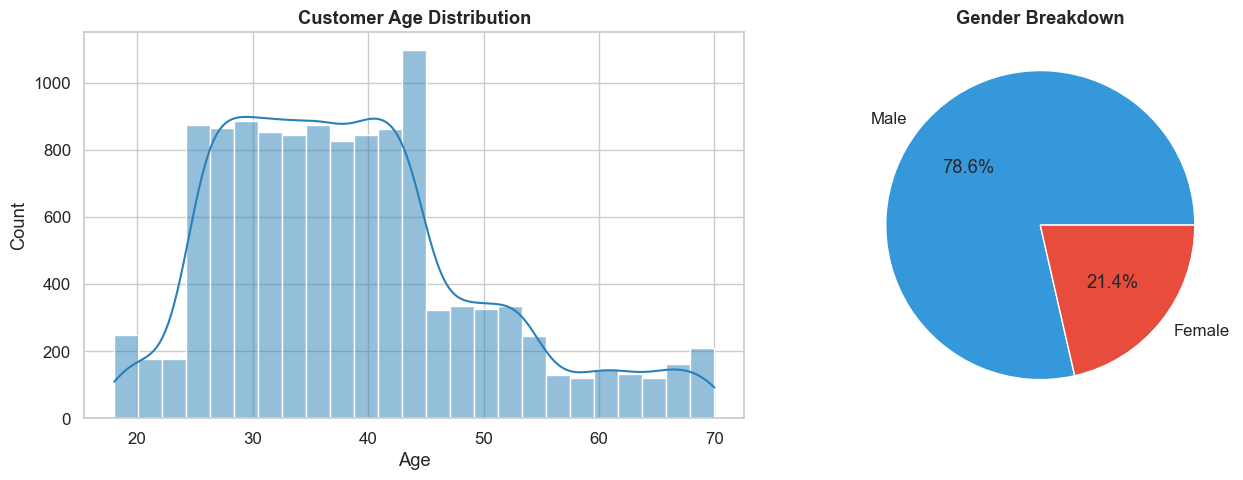

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'], bins=25, kde=True, color='#2980b9', ax=axes[0])
axes[0].set_title("Customer Age Distribution", fontweight='bold')

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], ax=axes[1])
axes[1].set_title("Gender Breakdown", fontweight='bold')
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


## 3. Plot Budget vs. Annual Income

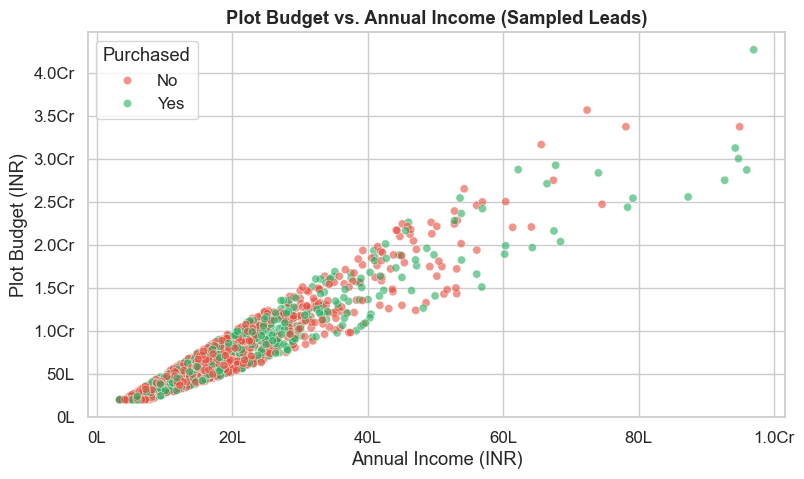

In [3]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='Annual_Income',
    y='Plot_Budget',
    hue='Purchased',
    palette={'Yes': '#27ae60', 'No': '#e74c3c'},
    alpha=0.6,
    s=35
)
plt.title("Plot Budget vs. Annual Income (Sampled Leads)", fontweight='bold')
plt.xlabel("Annual Income (INR)")
plt.ylabel("Plot Budget (INR)")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x/100000:.0f}L" if x < 10000000 else f"{x/10000000:.1f}Cr")
plt.gca().yaxis.set_major_formatter(lambda y, pos: f"{y/100000:.0f}L" if y < 10000000 else f"{y/10000000:.1f}Cr")
plt.show()


## 4. Sales Funnel Drop-off Analysis

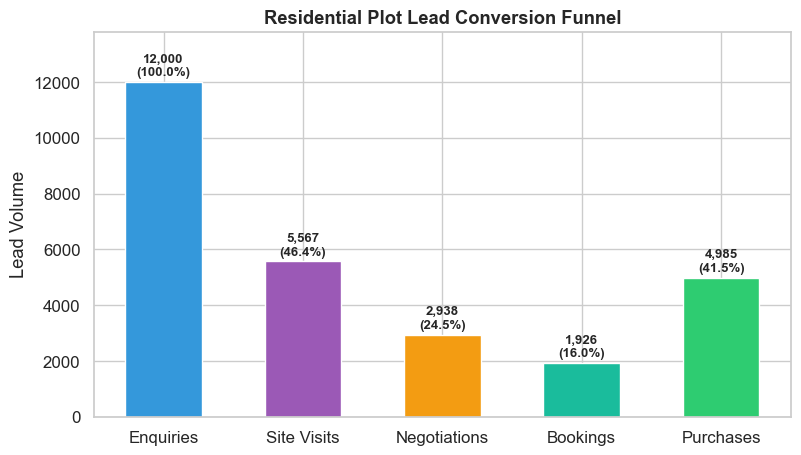

In [4]:
stages = ["Enquiries", "Site Visits", "Negotiations", "Bookings", "Purchases"]
counts = [
    len(df),
    (df['Site_Visit'] == 'Yes').sum(),
    (df['Negotiation_Done'] == 'Yes').sum(),
    (df['Booking_Done'] == 'Yes').sum(),
    (df['Purchased'] == 'Yes').sum()
]
pcts = [round(c / len(df) * 100, 1) for c in counts]

plt.figure(figsize=(9, 5))
bars = plt.bar(stages, counts, color=['#3498db', '#9b59b6', '#f39c12', '#1abc9c', '#2ecc71'], width=0.55)
plt.title("Residential Plot Lead Conversion Funnel", fontweight='bold')
plt.ylabel("Lead Volume")
for bar, pct, c in zip(bars, pcts, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120, f"{c:,}\n({pct}%)", ha='center', va='bottom', fontweight='bold', fontsize=9.5)
plt.ylim(0, len(df) * 1.15)
plt.show()


## 5. Age Group Analysis (Project Guide Section 6)

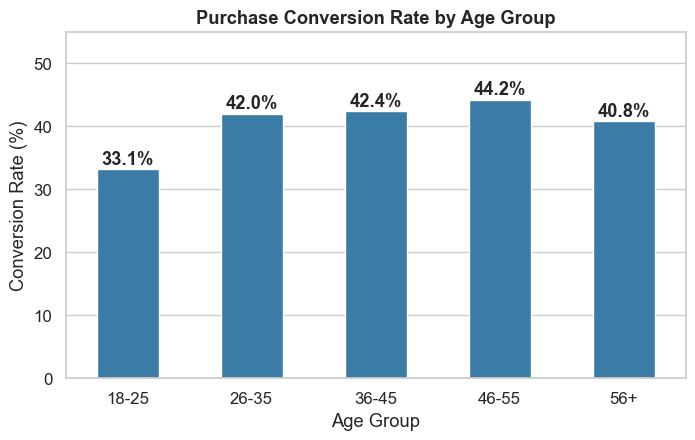

,Age_Group,Total_Leads,Buyers,Avg_Probability,Conversion_Pct
0,18-25,1056,350,0.353132,33.143939
1,26-35,4286,1801,0.418891,42.020532
2,36-45,4081,1729,0.426001,42.367067
3,46-55,1562,691,0.435243,44.238156
4,56+,1015,414,0.410878,40.788177


In [5]:
bins = [17, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_summary = df.groupby('Age_Group', observed=False).agg(
    Total_Leads=('Customer_ID', 'count'),
    Buyers=('Purchased', lambda x: (x == 'Yes').sum()),
    Avg_Probability=('Purchase_Probability', 'mean')
).reset_index()

age_summary['Conversion_Pct'] = (age_summary['Buyers'] / age_summary['Total_Leads']) * 100

plt.figure(figsize=(8, 4.5))
sns.barplot(data=age_summary, x='Age_Group', y='Conversion_Pct', color='#2980b9', width=0.5)
plt.title("Purchase Conversion Rate by Age Group", fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
for idx, row in age_summary.iterrows():
    plt.text(idx, row['Conversion_Pct'] + 0.8, f"{row['Conversion_Pct']:.1f}%", ha='center', fontweight='bold')
plt.ylim(0, 55)
plt.show()
age_summary
